# SMBH + Host

This notebook carries out the modeling considering the SMBH gravity and the host galaxy gravity. These comprise the main results of the paper. 

In [1]:
import numpy as np
from SMBH_fitter import ModelVelocity, log_prob, MCMC, ReadData

In [2]:
#This deactivates the threading from numpy and is useful to do to make sure the threading from emcee is not affected by the threading from numpy. 
import os
os.environ["OMP_NUM_THREADS"] = "1"

## Initilizations

Here we first read the data file, using the [ReadData](readData.py) object. This is just for conveniency, but it is simply a function that reads and stores the relevant numbers in the file [data.dat](data.dat). 

The second step is to initialize the [ModelVelocity](modelVelocity.py) object, which holds a number of values relevant for the modeling and creates the interpolated values of the F and g functions. See the [README file](README.md) for more details. 

Finally, we set the boundaries for each of the parameters to be used during the MCMC. 

In [3]:
#Read the measurements. 
data = ReadData("data/data.dat")

In [4]:
#Initialize the modeling object. This takes some time as some functions need to be interpolated. 
modelv = ModelVelocity(data)

## Preferred Model

This calculation represents the main result of the paper, and produces the outputs that generate Figures 2 and S18.

In [5]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0  #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.50,  2.01 #Sersic index 
Re_host_min, Re_host_max     = 1.1 ,  1.6  #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0  #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([n_host_min,  log_Mhost_min, Re_host_min, log_Mbh_min])
params_max = np.array([n_host_max,  log_Mhost_max, Re_host_max, log_Mbh_max])

In [6]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([1.5, 10.5, 1.5, 10.])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)

In [7]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.all_params.constrained_sersic.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.all_params.txt")

100%|██████████| 5000/5000 [16:54<00:00,  4.93it/s]


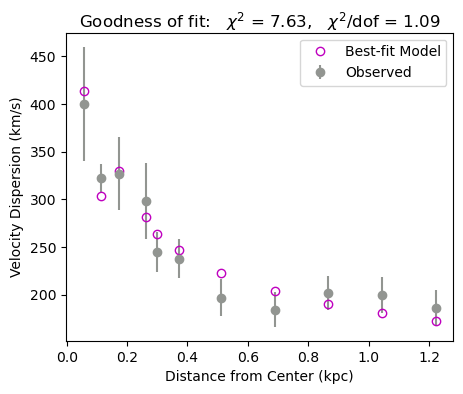

In [8]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

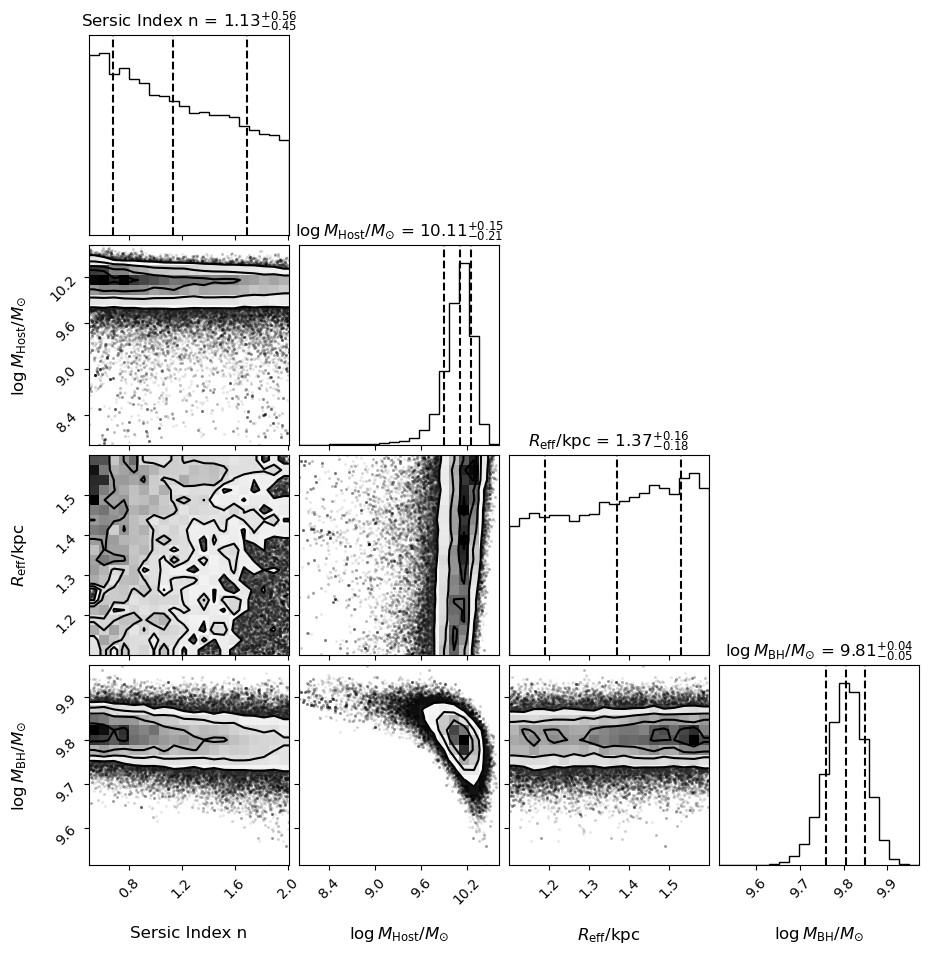

In [9]:
#Make the corner plot.
myMCMC.corner_plot()

# Only [C ii] 7 data points

Fit using only the [CII] data

In [10]:
#Read the measurements. 
data_cii = ReadData("data/data_cii_only.dat")

In [11]:
#Initialize the modeling object. This takes some time as some functions need to be interpolated. 
modelv_cii = ModelVelocity(data_cii)

In [12]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0 #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.50,  2.01 #Sersic index 
Re_host_min, Re_host_max     = 1.1 ,  1.6 #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([n_host_min,  log_Mhost_min, Re_host_min, log_Mbh_min])
params_max = np.array([n_host_max,  log_Mhost_max, Re_host_max, log_Mbh_max])

In [13]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([1.5, 10.5, 1.5, 10.])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)

In [14]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv_cii, log_prob, data_cii.sigma_obs, data_cii.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.all_params.constrained_sersic.cii_only.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.all_params.constrained_sersic.cii_only.txt")

100%|██████████| 5000/5000 [10:54<00:00,  7.64it/s]


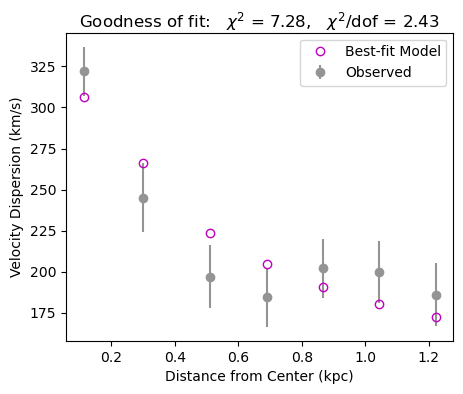

In [15]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

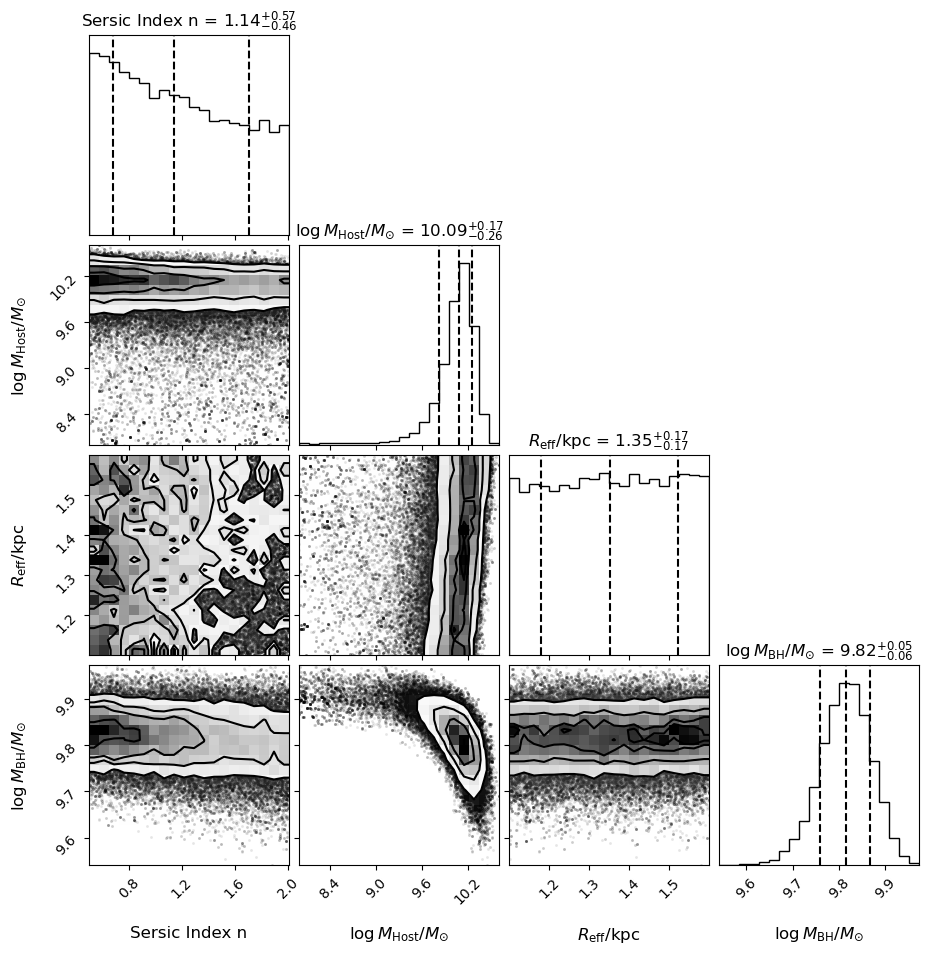

In [16]:
#Make the corner plot.
myMCMC.corner_plot()

# Fixed $M^{\rm Total}_{\rm Host} = 2.5\times 10^{11}~M_{\odot}$ 

This is the same as the previous fit but fixing the host galaxy mass to the value estimated by Diaz-Santos et al. (2018)

In [17]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 8.5 , 11.0 #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.45, 10.0 #Sersic index 
Re_host_min, Re_host_max     = 0.5 , 10.0 #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([n_host_min,  log_Mhost_min, Re_host_min, log_Mbh_min])
params_max = np.array([n_host_max,  log_Mhost_max, Re_host_max, log_Mbh_max])

In [18]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([4.0, np.log10(2.5e11), 1.5, 10.])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)
ifix[1] = True

In [19]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.all_params.fixed_host_mass.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.all_params.fixed_host_mass.txt")

100%|██████████| 5000/5000 [17:02<00:00,  4.89it/s]


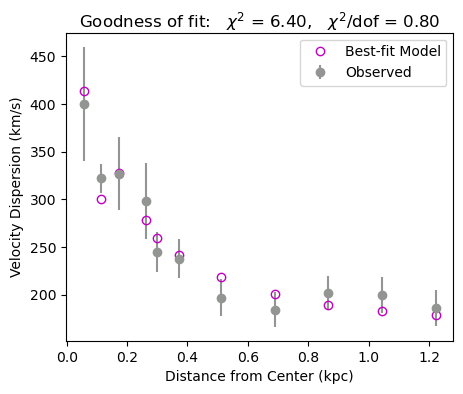

In [20]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

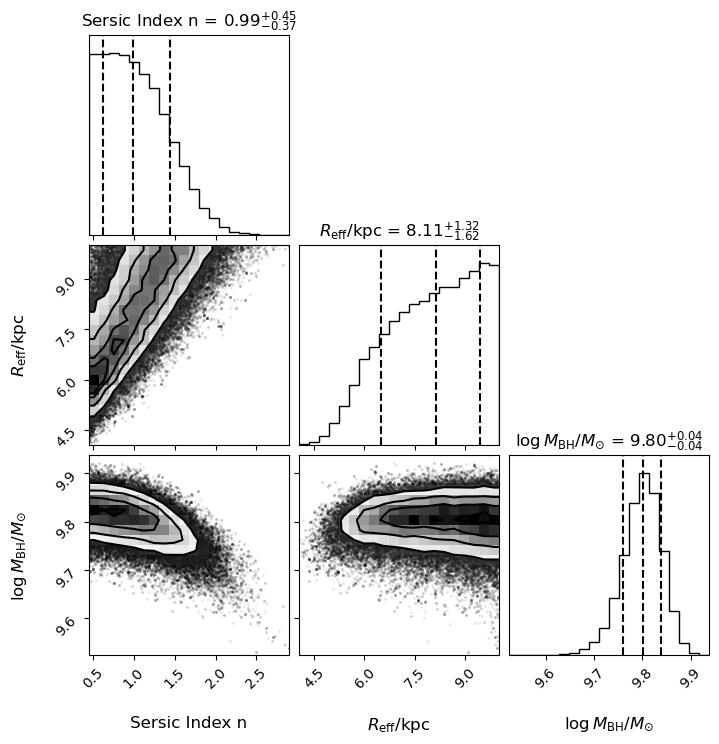

In [21]:
#Make the corner plot.
myMCMC.corner_plot()

# Full range for all parameters

This is the same as the preferred model but without placing significant constraints on the Sersic index and effective radius of the host galaxy. The results for this model are not shown in Table S5, but are discussed in Section 11.2.

In [22]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0  #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.45, 10.0 #Sersic index 
Re_host_min, Re_host_max     = 0.50, 10.0  #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0  #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([n_host_min,  log_Mhost_min, Re_host_min, log_Mbh_min])
params_max = np.array([n_host_max,  log_Mhost_max, Re_host_max, log_Mbh_max])

In [23]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([4.0, 10.5, 1.5, 10.])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)

In [24]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.all_params.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.all_params.txt")

100%|██████████| 5000/5000 [16:02<00:00,  5.19it/s]


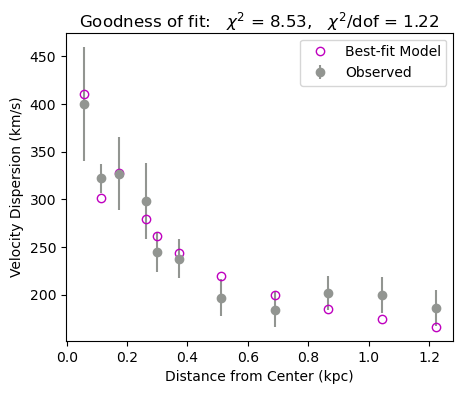

In [25]:
#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

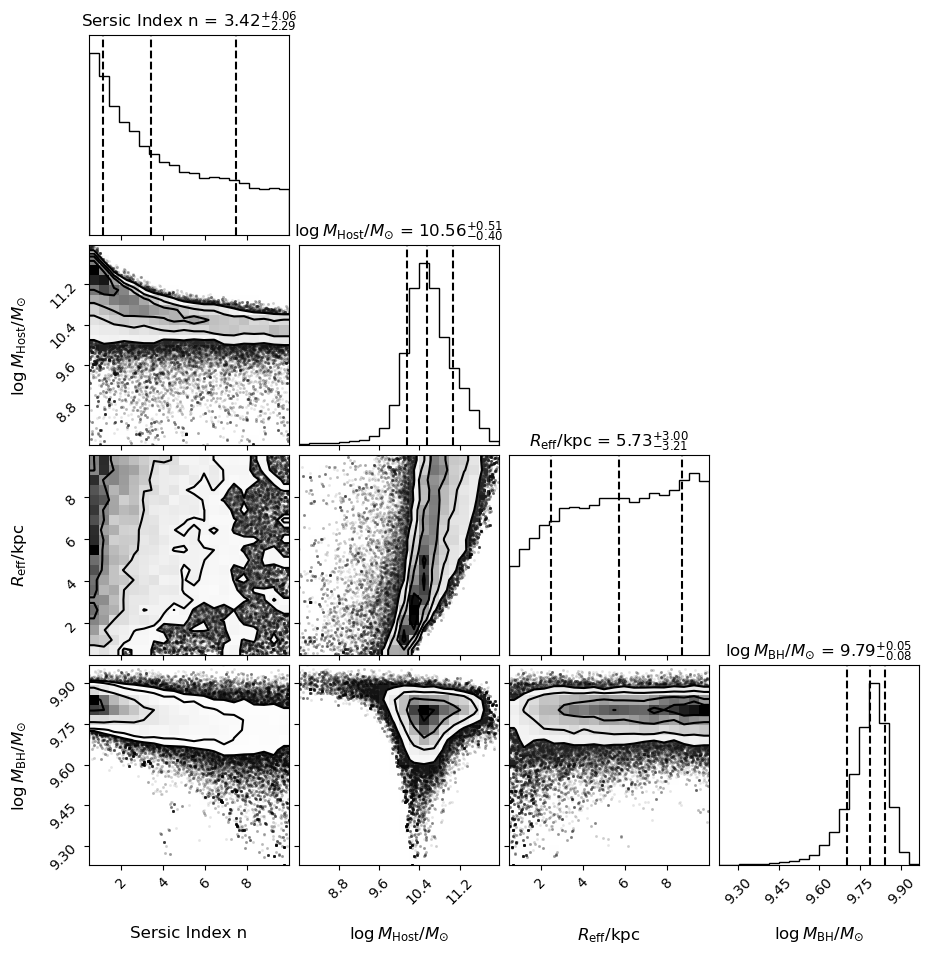

In [26]:
#Make the corner plot.
myMCMC.corner_plot()